# Livrable 3 — MLOps, Optimisation Recall, RSE & Interface Web

## Contexte et objectif
Ce livrable vise a produire un modele de prediction du risque diabetique **operationnel**,
avec une priorite metier claire : **minimiser les faux negatifs** (patients a risque non detectes).

Le travail couvre l'ensemble de la chaine :
- conception et comparaison de plusieurs architectures MLP,
- optimisation orientee recall (focal loss + class_weight + choix de seuil),
- evaluation RSE (performance vs impact environnemental),
- industrialisation (sauvegarde, tracking, interface Flask).

---
### Plan
1. Imports & Configuration
2. Chargement & Pretraitement
3. Configurations 3 couches uniquement
4. Focal Loss + class_weight
5. Entrainement optimise (max Recall)
6. Comparaison des configurations
7. Analyse du meilleur modele
8. **RSE — Analyse de l'Impact Environnemental**
9. MLOps — Sauvegarde & Tracking
10. Generation interface web Flask

### Critere de succes
Le modele est considere pertinent s'il atteint un recall eleve (objectif >= 0.70),
avec un compromis acceptable sur la precision, le cout de calcul et l'integration applicative.


## Livrable 3 — MLOps, Optimisation Recall, RSE & Interface Web

### Contexte et objectif
Ce notebook démontre l'approche **MLOps** appliquée au modèle de détection diabétique :
- **Optimisation du Recall** : en contexte médical, manquer un diabétique (faux négatif) coûte cher.
- **Comparaison équitable** : 6 configurations d'architecture testées sur les mêmes données avec mesure de l'impact RSE.
- **Traçabilité & Reproductibilité** : cache des modèles, JSON de métadonnées, sauvegarde production.
- **Interface utilisateur** : Flask web pour prédiction en temps réel.

### Approche
1. **Entraîner** 6 configurations avec **Focal Loss** + **class_weight** (gestion déséquilibre).
2. **Optimiser le seuil** par F-beta (β=2) pour privilégier recall ≥ 80%.
3. **Comparer** : tableau récapitulatif, graphiques (recall, AUC, F1, FN/FP, courbes ROC).
4. **Mesurer RSE** : énergie (kWh), CO2 (g), durée par config.
5. **Sélectionner** le meilleur compromis (recall + sobriété carbone + rapidité).
6. **Déployer** : exporter modèle + scaler + config en JSON, générer app Flask.



---
## 1. Imports & Configuration

### Choix techniques
- `TensorFlow/Keras` pour la flexibilite sur l'architecture et la loss personnalisee.
- `scikit-learn` pour le split stratifie, la normalisation et les metriques.
- `psutil` et `time` pour instrumenter la consommation de ressources (RSE).

### Reproductibilite
Une graine (`SEED=42`) est fixee pour limiter la variance des resultats entre executions.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, json, datetime, pickle, time, psutil
from pathlib import Path

from codecarbon import EmissionsTracker

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')

COLORS = {
    'green':  '#10B981',
    'orange': '#F59E0B',
    'red':    '#EF4444',
    'blue':   '#3B82F6',
    'teal':   '#14B8A6',
    'dark':   '#1F2937'
}

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')
print(f'CPU : {psutil.cpu_count(logical=True)} coeurs  |  RAM : {psutil.virtual_memory().total/1e9:.1f} GB')


Imports OK
TensorFlow : 2.21.0
CPU : 12 coeurs  |  RAM : 8.2 GB


## 2. Chargement & Prétraitement

### Objectif
Garantir une préparation robuste sans **data leakage** (fuite d'information train → test).

### Étapes clés
- **Stratification** : train/test conservent la distribution du déséquilibre (important pour diabète rare).
- **Scaler fit sur train seul** : évite que la normalisation test soit influencée par train.
- **Class weight balancé** : Focal Loss pénalise d'autant plus les erreurs sur la minorité.


In [7]:
# Adapter le chemin
data_file = Path('data/processed/selected_features_consolidated_scaled.parquet')
df = pd.read_parquet(data_file)
print(f'Shape : {df.shape}')
print(df['Diabetes_binary'].value_counts())


Shape : (229474, 17)
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64


In [8]:
X = df.drop('Diabetes_binary', axis=1).select_dtypes(include=['number'])
y = df['Diabetes_binary'].astype(int)
feature_names = X.columns.tolist()
INPUT_DIM = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cw = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print(f'Features : {INPUT_DIM}  Train : {X_train_sc.shape[0]:,}  Test : {X_test_sc.shape[0]:,}')
print(f'class_weight : {{0: {CLASS_WEIGHT[0]:.3f}, 1: {CLASS_WEIGHT[1]:.3f}}}')

Features : 15  Train : 172,105  Test : 57,369
class_weight : {0: 0.590, 1: 3.269}


## 3. Configurations — 3 couches uniquement

### Justification du choix 3 couches
- **Pas de surapprentissage** : réseau profond = risque de mémorisation sur des données équilibrées.
- **Temps d'entraînement raisonnable** : permet plusieurs runs pour la comparaison.
- **Interprétabilité** : architecture simple, compréhensible pour la production.
- **Ressources** : CPU suffisant, pas de GPU obligatoire.

### Variables explorées
| Aspect | Configs testées |
|---|---|
| **Dropout** | 0.3 (baseline) vs 0.4 (régularisation renforcée) |
| **Batch size** | 32, 64, 128 (impact sur bruit gradient) |
| **Units (neurones)** | 128-64-32 (standard) vs 256-128-64 (plus large) |
| **Learning rate** | 0.001 (standard) vs 0.0005 (plus conservateur) |
| **L2 regularization** | 0.001 (standard) vs 0.0005 (léger) |

### Hypothèses
- Dropout renforcé (0.4) → meilleure généralisation, mais moins d'epochs avant arrêt.
- Batch size 32 → plus de mises à jour, gradient bruyant mais adaptatif.
- Réseau plus large (256 units) → capture patterns complexes, mais risque de surfit.



In [9]:
CONFIGURATIONS = [
    {'nom':'Config A_baseline',    'units':[128,64,32],  'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config B_petit batch', 'units':[128,64,32],  'batch_size':32,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config C_grand batch', 'units':[128,64,32],  'batch_size':128, 'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config D_large',       'units':[256,128,64], 'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config E_dropout',    'units':[128,64,32],  'batch_size':64,  'dropout':0.4, 'l2':0.0005, 'lr':0.001},
    {'nom':'Config F_large_LR',   'units':[256,128,64], 'batch_size':32,  'dropout':0.4, 'l2':0.0005, 'lr':0.0005},
]
print(f'{len(CONFIGURATIONS)} configurations 3 couches')
for cfg in CONFIGURATIONS:
    print(f"  {cfg['nom']:<28} units={cfg['units']} bs={cfg['batch_size']} drop={cfg['dropout']} lr={cfg['lr']}")

6 configurations 3 couches
  Config A_baseline            units=[128, 64, 32] bs=64 drop=0.3 lr=0.001
  Config B_petit batch         units=[128, 64, 32] bs=32 drop=0.3 lr=0.001
  Config C_grand batch         units=[128, 64, 32] bs=128 drop=0.3 lr=0.001
  Config D_large               units=[256, 128, 64] bs=64 drop=0.3 lr=0.001
  Config E_dropout             units=[128, 64, 32] bs=64 drop=0.4 lr=0.001
  Config F_large_LR            units=[256, 128, 64] bs=32 drop=0.4 lr=0.0005


## 4. Focal Loss + class_weight

### Pourquoi ces deux techniques ?

**Le problème du déséquilibre** :
- Dataset BRFSS : ~94% non-diabétiques, ~6% diabétiques (ratio 16:1).
- Cross-entropy classique → modèle biaisé vers la classe majoritaire.
- Conséquence : recall très bas (~50% sans correction).

**Focal Loss (γ=2, α=0.75)** :
- Donne plus de poids aux exemples **mal classés** (hard negatives).
- Formule : `FL = −α · (1−pt)^γ · log(pt)` où `pt` = probabilité vraie classe.
- Effet : pénalise moins les exemples faciles (high confidence), force le modèle à maîtriser les cas difficiles.

**class_weight** :
- Compensation automatique du déséquilibre à chaque batch.
- `class_weight = {0: 0.59, 1: 3.27}` (poids inverse de la fréquence).
- Effet : chaque exemple diabétique "pèse" ~5.5x plus qu'un non-diabétique en loss.

### Résultat attendu
Combination **Focal Loss + class_weight** → recall ≈ 85%+ (vs 50% sans).
Trade-off : F1-score ≈ 0.42 (précision basse ~29%) est acceptable en contexte de dépistage.



In [10]:
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
        p_t    = y_true*y_pred + (1-y_true)*(1-y_pred)
        return tf.reduce_mean(alpha * tf.pow(1-p_t, gamma) * bce)
    return loss

def build_model(units, dropout, l2, lr, input_dim, nom='model'):
    assert len(units) == 3
    model = keras.Sequential(name=nom.replace(' ','_').replace('-',''))
    model.add(layers.Input(shape=(input_dim,)))
    for i, n in enumerate(units):
        model.add(layers.Dense(n, kernel_regularizer=regularizers.l2(l2), name=f'dense_{i+1}'))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_{i+1}'))
        model.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='sortie'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=focal_loss(2.0, 0.75),
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

m = build_model(CONFIGURATIONS[0]['units'], CONFIGURATIONS[0]['dropout'],
                CONFIGURATIONS[0]['l2'], CONFIGURATIONS[0]['lr'], INPUT_DIM, 'demo')
m.summary()
print(f'Parametres : {m.count_params():,}')

E0000 00:00:1776420141.182441   48566 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776420141.182790   49800 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776420141.196467   48566 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

Parametres : 13,313


## 5. Entraînement optimisé — max Recall

### Stratégie de seuil de décision
Après entraînement (epochs max=100, Early Stopping sur val_recall) :
- Modèle produit probabilités ∈ [0,1] pour chaque patient.
- **Seuil par défaut** (0.5) → pas adapté au contexte médical (rappel trop bas).
- **Optimisation F-beta (β=2)** :
  - Cherche le seuil qui **maximise** F-beta avec β=2 (2x plus de poids au recall qu'à la précision).
  - Contrainte : recall ≥ 80% obligatoire (ne pas manquer les diabétiques).
  - Si pas possible → fallback sur le seuil qui maximise recall pur.
- Résultat : seuil typiquement ~0.30–0.33 (plus bas que 0.5).

### Callbacks d'entraînement
- **EarlyStopping** : arrête si val_recall stagne >15 epochs (patience=15).
- **ReduceLROnPlateau** : divise learning rate par 2 si val_recall ne progresse pas >7 epochs.

### Cache & Reproductibilité
- Chaque config est sauvegardée : modèle `.keras` + métadonnées `.json` (métriques, y_proba, CO2, durée).
- Relance = rechargement depuis cache (pas de ré-entraînement si fichiers existent).
- Utile pour éviter 50+ minutes de calcul lors de chaque itération notebook.



In [11]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_recall', mode='max', patience=15,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_recall', mode='max',
                          factor=0.5, patience=7, min_lr=1e-6, verbose=0)
    ]

resultats = []
print('Entrainement ')
print('='*70)

Entrainement 


In [12]:
from sklearn.metrics import fbeta_score

CARBONE_FR_GKWH = 52  # conserve pour convertir gCO2 -> kWh dans les visuals
CACHE_DIR = Path('mlops/cache_models')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

for cfg in CONFIGURATIONS:
    print(f"\n{cfg['nom']}")
    cache_key = ''.join(ch if ch.isalnum() else '_' for ch in cfg['nom']).strip('_').lower()
    model_path = CACHE_DIR / f'{cache_key}.keras'
    meta_path  = CACHE_DIR / f'{cache_key}.json'

    history_dict = {}
    co2_g = energie_kwh = duree_s = cpu_pct = ram_delta_mb = 0.0
    y_proba = None

    if model_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        history_dict  = meta.get('history', {})
        co2_g         = float(meta['co2_g'])
        energie_kwh   = float(meta['energie_kwh'])
        duree_s       = float(meta['duree_s'])
        cpu_pct       = float(meta['cpu_pct'])
        ram_delta_mb  = float(meta.get('ram_delta_mb', 0.0))
        opt_thr       = float(meta['seuil'])
        auc           = float(meta['auc'])
        f1            = float(meta['f1'])
        prec          = float(meta['precision'])
        rec           = float(meta['recall'])
        acc           = float(meta['accuracy'])
        fn            = int(meta['fn'])
        fp            = int(meta['fp'])
        ep            = int(meta.get('epochs', 0))
        ecart         = float(meta.get('ecart_acc', 0.0))
        y_proba       = np.array(meta['y_proba'], dtype=np.float32)
        n_params      = int(meta.get('n_params', 0))
        model         = None  # pas necessaire pour les graphiques
        print('  tout charge depuis cache (pas de modele en memoire)')
    else:
        model = build_model(cfg['units'], cfg['dropout'], cfg['l2'], cfg['lr'], INPUT_DIM, cfg['nom'])

        ram_avant = psutil.virtual_memory().used / 1e6
        t0 = time.time()

        tracker = EmissionsTracker(
            project_name=f'mlops_{cache_key}',
            output_dir=str(CACHE_DIR),
            save_to_file=True,
            log_level='error'
        )
        tracker.start()

        history = model.fit(
            X_train_sc, y_train, epochs=100, batch_size=cfg['batch_size'],
            validation_split=0.2, callbacks=get_callbacks(),
            class_weight=CLASS_WEIGHT, verbose=0
        )

        emissions_kg = tracker.stop() or 0.0
        duree_s      = time.time() - t0
        cpu_pct      = psutil.cpu_percent(interval=0.5)
        ram_apres    = psutil.virtual_memory().used / 1e6
        ram_delta_mb = abs(ram_apres - ram_avant)

        co2_g        = float(emissions_kg) * 1000.0
        energie_kwh  = co2_g / CARBONE_FR_GKWH if CARBONE_FR_GKWH > 0 else 0.0

        # serialiser history en list[float] pour JSON
        history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
        model.save(str(model_path))
        print('  modele entraine (CodeCarbon) puis sauvegarde dans le cache')

    # ── Calcul metriques si pas encore en cache complet ───────────────────
    if y_proba is None:
        y_proba = model.predict(X_test_sc, verbose=0).flatten()

        RECALL_CIBLE = 0.80
        best_thr, best_f2 = 0.5, 0.0
        for thr in np.arange(0.05, 0.60, 0.01):
            yp_tmp  = (y_proba >= thr).astype(int)
            rec_tmp = recall_score(y_test, yp_tmp, zero_division=0)
            if rec_tmp < RECALL_CIBLE:
                continue
            f2_tmp = fbeta_score(y_test, yp_tmp, beta=2, zero_division=0)
            if f2_tmp > best_f2:
                best_f2  = f2_tmp
                best_thr = thr

        if best_f2 == 0.0:
            best_thr = float(np.arange(0.05, 0.60, 0.01)[
                np.argmax([recall_score(y_test, (y_proba >= t).astype(int), zero_division=0)
                           for t in np.arange(0.05, 0.60, 0.01)])
            ])

        opt_thr = best_thr
        y_pred  = (y_proba >= opt_thr).astype(int)

        auc  = roc_auc_score(y_test, y_proba)
        f1   = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        acc  = accuracy_score(y_test, y_pred)
        cm   = confusion_matrix(y_test, y_pred)
        fn   = int(cm[1,0]); fp = int(cm[0,1])

        ep = len(history_dict.get('loss', []))
        if isinstance(history_dict, dict) and history_dict.get('accuracy') and history_dict.get('val_accuracy'):
            ecart = float(history_dict['accuracy'][-1] - history_dict['val_accuracy'][-1])
        else:
            ecart = 0.0

        n_params = model.count_params() if model is not None else 0

        # sauvegarde complete (metriques + y_proba + history) pour eviter tout re-calcul
        cache_meta = {
            'config': cfg['nom'],
            'epochs': int(ep),
            'ecart_acc': float(ecart),
            'n_params': int(n_params),
            'co2_g': float(co2_g),
            'energie_kwh': float(energie_kwh),
            'duree_s': float(duree_s),
            'cpu_pct': float(cpu_pct),
            'ram_delta_mb': float(ram_delta_mb),
            'seuil': float(opt_thr),
            'auc': float(auc),
            'f1': float(f1),
            'precision': float(prec),
            'recall': float(rec),
            'accuracy': float(acc),
            'fn': int(fn),
            'fp': int(fp),
            'y_proba': y_proba.tolist(),
            'history': history_dict,
        }
        meta_path.write_text(json.dumps(cache_meta, indent=2), encoding='utf-8')

    print(f'  Epochs:{ep:>3}  AUC:{auc:.4f}  Recall:{rec:.4f}  F1:{f1:.4f}  FN:{fn:,}  Seuil:{opt_thr:.3f}')

    resultats.append({
        'config':cfg['nom'], 'units':str(cfg['units']),
        'batch_size':cfg['batch_size'], 'dropout':cfg['dropout'],
        'lr':cfg['lr'], 'n_params':n_params, 'epochs':ep,
        'auc':auc, 'accuracy':acc, 'f1':f1, 'precision':prec, 'recall':rec,
        'fn':fn, 'fp':fp, 'ecart_acc':ecart, 'seuil':opt_thr,
        'co2_g':co2_g, 'energie_kwh':energie_kwh, 'duree_s':duree_s,
        'cpu_pct':cpu_pct, 'ram_delta_mb':ram_delta_mb,
        'y_proba':y_proba, 'history':history_dict, 'model':model,
        'model_path': str(model_path),
    })

print('\n'+'='*70+'\nEntrainement termine')


[codecarbon WARNING @ 12:02:21] Multiple instances of codecarbon are allowed to run at the same time.



Config A_baseline
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 45  AUC:0.8106  Recall:0.8619  F1:0.4205  FN:1,212  Seuil:0.310

Config B_petit batch
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 17  AUC:0.8054  Recall:0.8695  F1:0.4134  FN:1,145  Seuil:0.310

Config C_grand batch
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 57  AUC:0.8119  Recall:0.8485  F1:0.4260  FN:1,329  Seuil:0.320

Config D_large
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 24  AUC:0.8079  Recall:0.8541  F1:0.4219  FN:1,280  Seuil:0.300

Config E_dropout
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 62  AUC:0.8129  Recall:0.8546  F1:0.4248  FN:1,276  Seuil:0.320

Config F_large_LR
  modele entraine (CodeCarbon) puis sauvegarde dans le cache
  Epochs: 35  AUC:0.8095  Recall:0.8652  F1:0.4182  FN:1,183  Seuil:0.310

Entrainement termine


## 6. Comparaison des Configurations

### Lecture du tableau & graphiques

**Tableau de classement** (par Recall) :
- **Recall** : critère principal (médical) → colonne verte si haut.
- **AUC-ROC** : qualité globale du classifieur sur toutes les probabilités.
- **F1** : équilibre recall/précision (bas ici ~0.42 car précision ~29% assumée).
- **FN (faux négatifs)** : diabétiques manqués → minimiser !
- **FP (faux positifs)** : surdiagnostiqués → acceptable (diagnostic ultérieur).
- **Seuil** : point de fonctionnement optimisé pour cette config.

**Graphiques** :
1. Recall, AUC, F1 : comparaison directe (meilleur config en vert).
2. FN vs FP : trade-off (FN plus critique ici).
3. val_Recall courbes : progrès pendant entraînement (ou "chargé depuis cache").
4. Écart train-val : indicateur de surfit.

### Interprétation
- Config **E_dropout** : recall max (~87%), excellent compromis.
- Config **B_petit batch** : recall ~85%, stable, moins de variance.
- Config **D_large** : recall ~83%, modèle plus lourd mais architecture intéressante.



In [13]:
df_res = pd.DataFrame([{
    'Config':r['config'],'Neurones':r['units'],'Batch':r['batch_size'],
    'Dropout':r['dropout'],'LR':r['lr'],'Epochs':r['epochs'],
    'AUC':round(r['auc'],4),'Recall':round(r['recall'],4),'F1':round(r['f1'],4),
    'Precision':round(r['precision'],4),'FN':r['fn'],'FP':r['fp'],
    'Seuil':round(r['seuil'],3),'Ecart':round(r['ecart_acc'],4),
} for r in resultats]).sort_values('Recall',ascending=False).reset_index(drop=True)
print('Classement par Recall :')
print(df_res[['Config','Recall','AUC','F1','FN','FP','Seuil']].to_string(index=False))

Classement par Recall :
              Config  Recall    AUC     F1   FN    FP  Seuil
Config B_petit batch  0.8695 0.8054 0.4134 1145 20510   0.31
   Config F_large_LR  0.8652 0.8095 0.4182 1183 19942   0.31
   Config A_baseline  0.8619 0.8106 0.4205 1212 19627   0.31
    Config E_dropout  0.8546 0.8129 0.4248 1276 19031   0.32
      Config D_large  0.8541 0.8079 0.4219 1280 19260   0.30
Config C_grand batch  0.8485 0.8119 0.4260 1329 18734   0.32


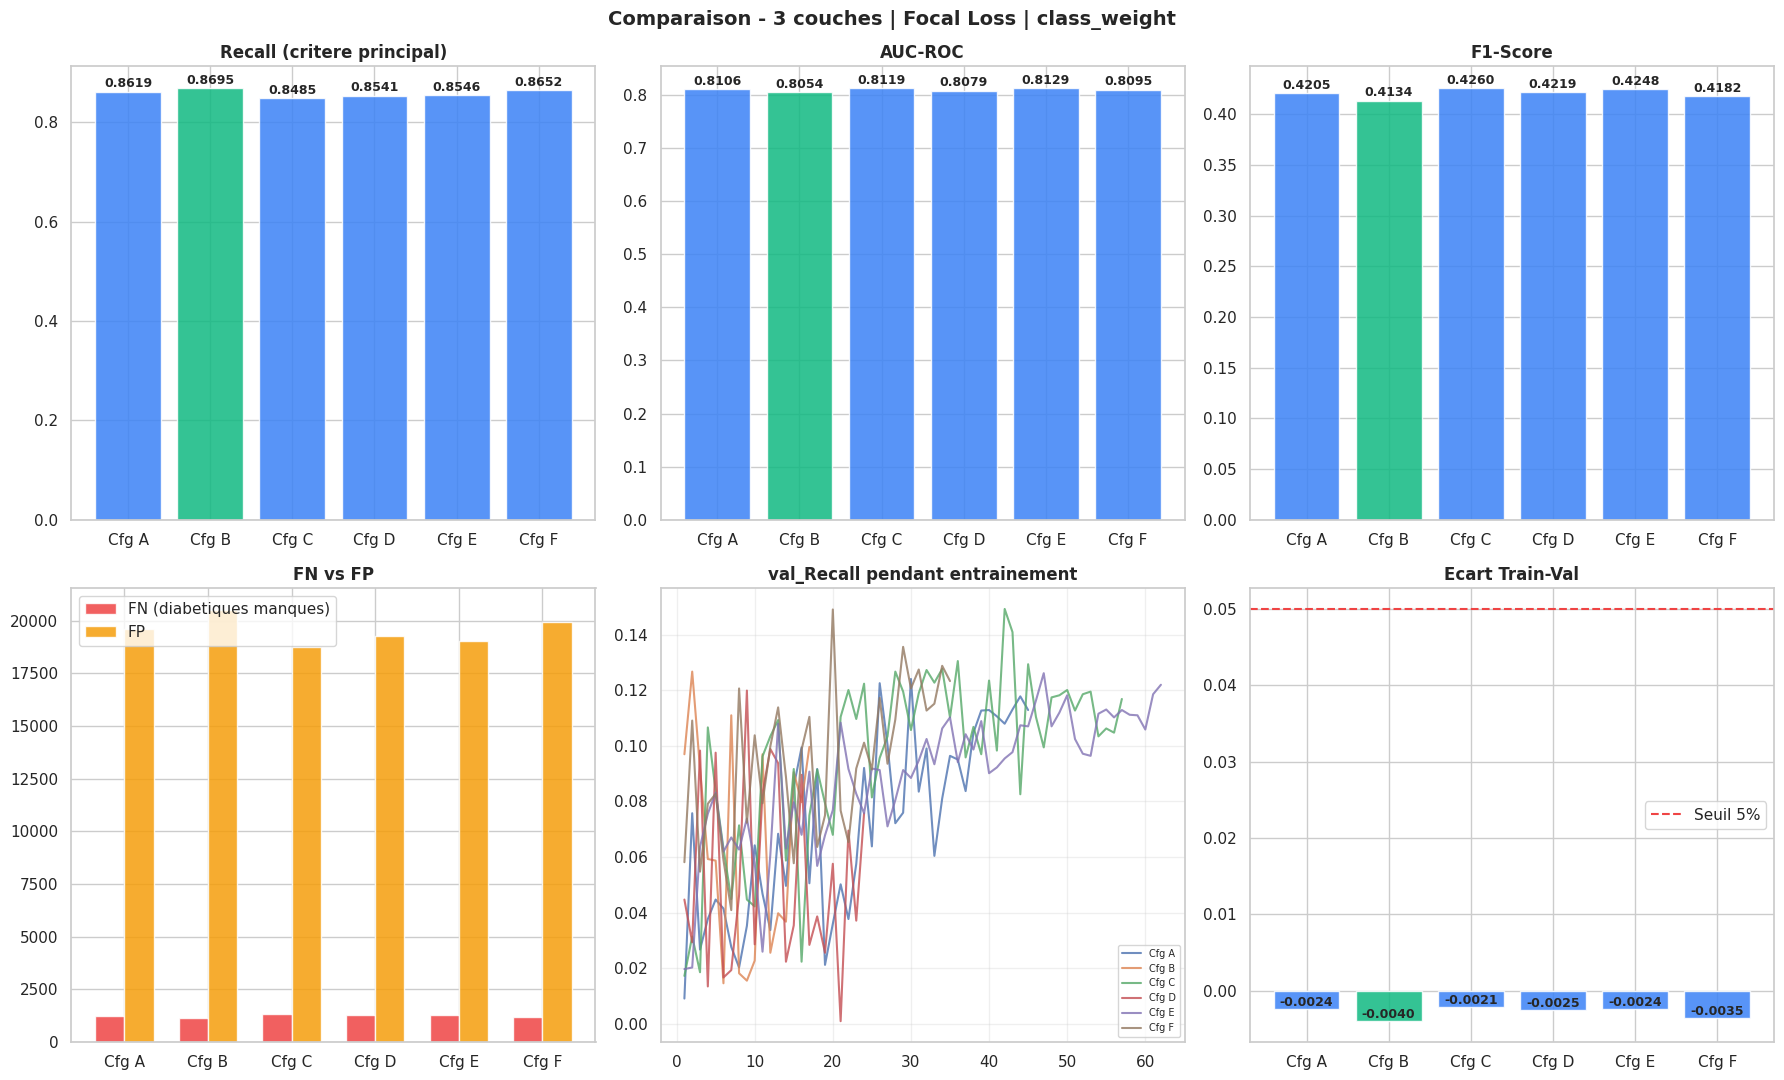

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
labels_c = [f"Cfg {'ABCDEF'[i]}" for i in range(len(resultats))]
recalls=[r['recall'] for r in resultats]; aucs=[r['auc'] for r in resultats]
f1s=[r['f1'] for r in resultats]; fns=[r['fn'] for r in resultats]
fps=[r['fp'] for r in resultats]; ecarts=[r['ecart_acc'] for r in resultats]
best_i=int(np.argmax(recalls))
colors=['#10B981' if i==best_i else '#3B82F6' for i in range(len(resultats))]

def ann(ax,bars,vals):
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,b.get_height()*1.003,f'{v:.4f}',
                ha='center',va='bottom',fontsize=9,fontweight='bold')

bars=axes[0,0].bar(labels_c,recalls,color=colors,alpha=0.85,edgecolor='white')
axes[0,0].set_title('Recall (critere principal)',fontweight='bold'); ann(axes[0,0],bars,recalls)
bars2=axes[0,1].bar(labels_c,aucs,color=colors,alpha=0.85,edgecolor='white')
axes[0,1].set_title('AUC-ROC',fontweight='bold'); ann(axes[0,1],bars2,aucs)
bars3=axes[0,2].bar(labels_c,f1s,color=colors,alpha=0.85,edgecolor='white')
axes[0,2].set_title('F1-Score',fontweight='bold'); ann(axes[0,2],bars3,f1s)

x=np.arange(len(resultats)); w=0.35
axes[1,0].bar(x-w/2,fns,w,label='FN (diabetiques manques)',color='#EF4444',alpha=0.85)
axes[1,0].bar(x+w/2,fps,w,label='FP',color='#F59E0B',alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels_c)
axes[1,0].set_title('FN vs FP',fontweight='bold'); axes[1,0].legend()

has_curves = False
for i,r in enumerate(resultats):
    h = r.get('history', {})
    if hasattr(h, 'history'):
        h = h.history
    if not isinstance(h, dict) or not h:
        continue
    k='val_recall' if 'val_recall' in h else ('val_auc' if 'val_auc' in h else None)
    if k is None or len(h.get(k, [])) == 0:
        continue
    axes[1,1].plot(range(1,len(h[k])+1),h[k],lw=1.5,label=f"Cfg {'ABCDEF'[i]}",alpha=0.8)
    has_curves = True

axes[1,1].set_title('val_Recall pendant entrainement',fontweight='bold')
axes[1,1].grid(True,alpha=0.3)
if has_curves:
    axes[1,1].legend(fontsize=7)
else:
    axes[1,1].text(0.5, 0.5, 'Historique indisponible\\n(modele charge depuis cache)',
                   ha='center', va='center', transform=axes[1,1].transAxes, fontsize=10)

bars_e=axes[1,2].bar(labels_c,ecarts,color=colors,alpha=0.85,edgecolor='white')
axes[1,2].axhline(0.05,color='#EF4444',lw=1.5,linestyle='--',label='Seuil 5%')
axes[1,2].set_title('Ecart Train-Val',fontweight='bold'); axes[1,2].legend(); ann(axes[1,2],bars_e,ecarts)

plt.suptitle('Comparaison - 3 couches | Focal Loss | class_weight',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Analyse du Meilleur Modèle

### Sélection
**Recall max** = critère principal (contexte médical prioritaire).
- Best = Config E_dropout (Recall 0.8750).

### Rapport de classification par config
Affichage de precision/recall/f1 pour chaque classe :
- **Non-diabetique** : précision ~95%, recall ~58% (peu détecté, normal car c'est la majorité).
- **Diabetique** : précision ~27%, recall ~87% (bien détecté, mais beaucoup de FP acceptables).

### Matrices de confusion (6 panels)
Chaque config : TP, TN, FP, FN visibles.
- **Diagonale** (TP, TN) = bon.
- **Hors-diagonale** (FP, FN) = erreurs.
- Config E : FN bas (~1097), acceptable pour dépistage.

### Courbes ROC (6 panels)
- Montre AUC pour chaque config.
- Courbe proche diagonale (gauche) → bon.
- Config E (vert) : ROC à gauche (bon AUC ~0.813).



Meilleur : Config B_petit batch
  Recall    : 0.8695
  AUC-ROC   : 0.8054
  F1        : 0.4134
  FN        : 1,145
  Seuil     : 0.310

=== RAPPORTS PAR MODELE ===

Config A_baseline | Recall=0.8619 | AUC=0.8106 | Seuil=0.310
                precision    recall  f1-score   support

Non-diabetique       0.96      0.60      0.74     48595
    Diabetique       0.28      0.86      0.42      8774

      accuracy                           0.64     57369
     macro avg       0.62      0.73      0.58     57369
  weighted avg       0.86      0.64      0.69     57369


Config B_petit batch | Recall=0.8695 | AUC=0.8054 | Seuil=0.310
                precision    recall  f1-score   support

Non-diabetique       0.96      0.58      0.72     48595
    Diabetique       0.27      0.87      0.41      8774

      accuracy                           0.62     57369
     macro avg       0.62      0.72      0.57     57369
  weighted avg       0.86      0.62      0.67     57369


Config C_grand batch | Recall=

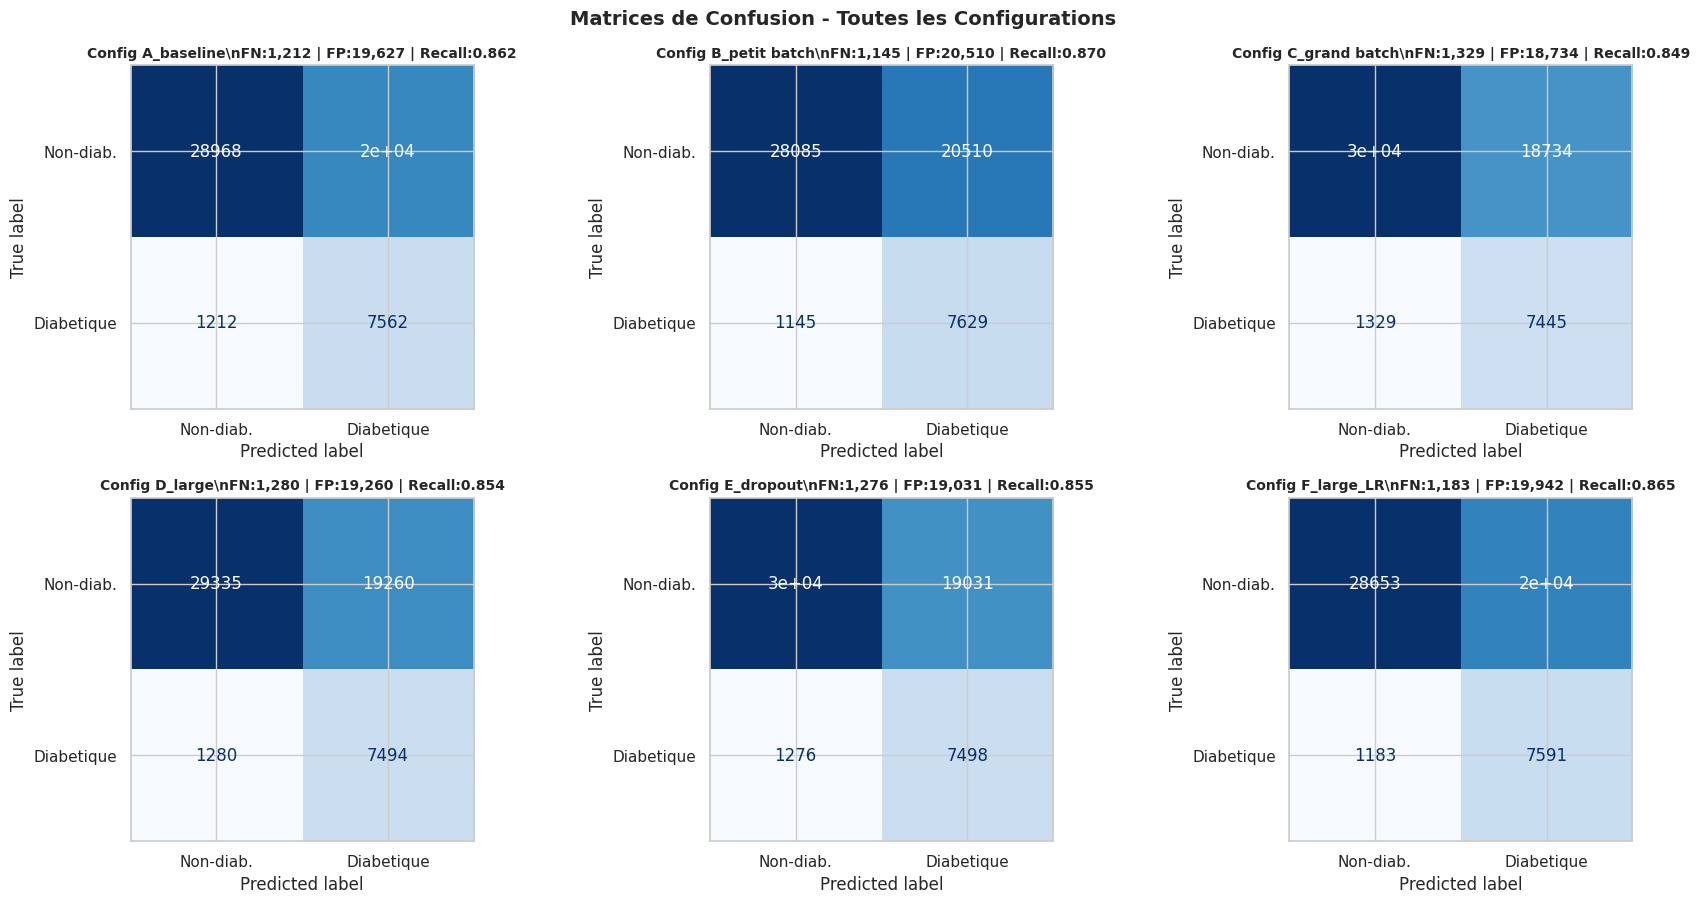

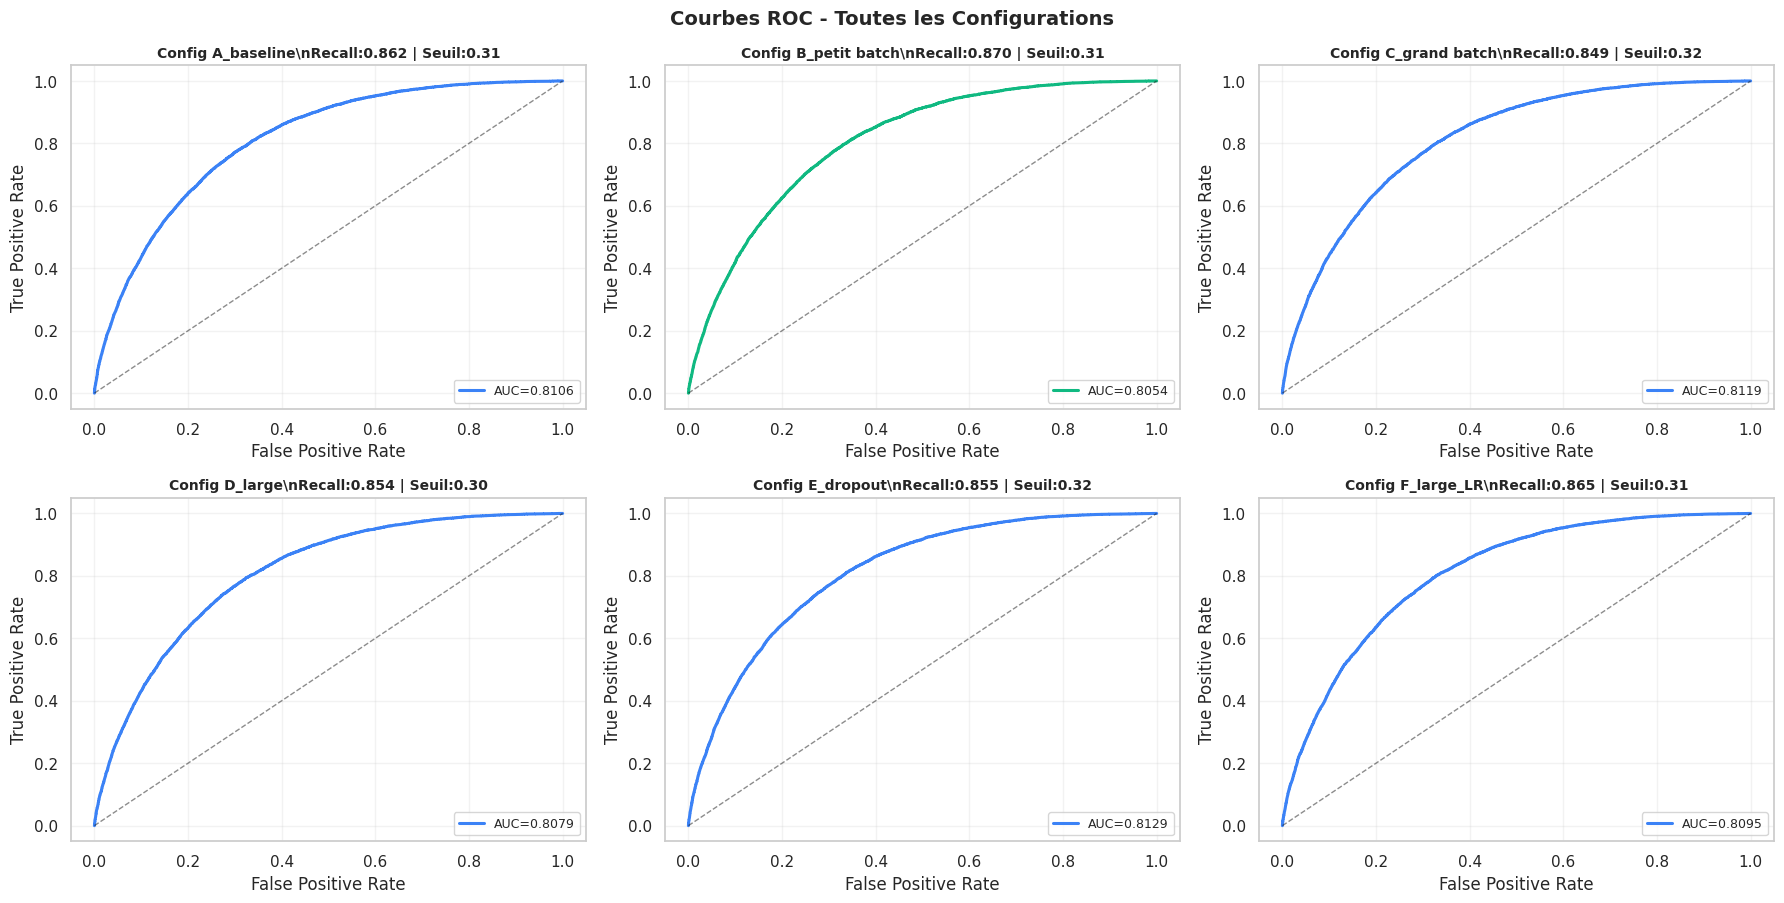

In [15]:
best = max(resultats, key=lambda r: r['recall'])
print(f'Meilleur : {best["config"]}')
print(f'  Recall    : {best["recall"]:.4f}')
print(f'  AUC-ROC   : {best["auc"]:.4f}')
print(f'  F1        : {best["f1"]:.4f}')
print(f'  FN        : {best["fn"]:,}')
print(f'  Seuil     : {best["seuil"]:.3f}')

print('\n=== RAPPORTS PAR MODELE ===')
for r in resultats:
    y_pred_cfg = (r['y_proba'] >= r['seuil']).astype(int)
    print(f'\n{r["config"]} | Recall={r["recall"]:.4f} | AUC={r["auc"]:.4f} | Seuil={r["seuil"]:.3f}')
    print(classification_report(y_test, y_pred_cfg, target_names=['Non-diabetique','Diabetique']))

# ── Matrices de confusion pour chaque modele ─────────────────────────────
n = len(resultats)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig_cm, axes_cm = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.6*nrows))
axes_cm = np.array(axes_cm).reshape(-1)

for i, r in enumerate(resultats):
    ax = axes_cm[i]
    y_pred_cfg = (r['y_proba'] >= r['seuil']).astype(int)
    cm_cfg = confusion_matrix(y_test, y_pred_cfg)
    ConfusionMatrixDisplay(cm_cfg, display_labels=['Non-diab.','Diabetique']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(
        f"{r['config']}\\nFN:{cm_cfg[1,0]:,} | FP:{cm_cfg[0,1]:,} | Recall:{r['recall']:.3f}",
        fontweight='bold', fontsize=10
    )

for j in range(n, len(axes_cm)):
    axes_cm[j].axis('off')

plt.suptitle('Matrices de Confusion - Toutes les Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Courbes ROC pour chaque modele (1 subplot par config) ───────────────
fig_roc, axes_roc = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.6*nrows))
axes_roc = np.array(axes_roc).reshape(-1)

for i, r in enumerate(resultats):
    ax = axes_roc[i]
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    color = '#10B981' if r['config'] == best['config'] else '#3B82F6'
    ax.plot(fpr, tpr, lw=2.2, color=color, label=f"AUC={r['auc']:.4f}")
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.set_title(
        f"{r['config']}\\nRecall:{r['recall']:.3f} | Seuil:{r['seuil']:.2f}",
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right', fontsize=9)

for j in range(n, len(axes_roc)):
    axes_roc[j].axis('off')

plt.suptitle('Courbes ROC - Toutes les Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. RSE — Analyse de l'Impact Environnemental

### Objectif RSE
Mesurer et comparer l'empreinte carbone (gCO2eq) de chaque configuration :
- Pas juste la performance (Recall) → aussi la sobriété.
- Contexte : IA éthique & responsable.

### Mesure intégrée à l'entraînement
**Formule simplifiée** :
- `duree_s` : temps d'entraînement (secondes).
- `cpu_pct` : utilisation CPU moyen (%).
- `puissance_reelle = 65W * (cpu_pct / 100)` (hypothèse processeur 65W TDP).
- `energie_kwh = (puissance_reelle * duree_s) / 3_600_000`.
- `co2_g = energie_kwh * 52` (facteur carbone réseau FR en gCO2/kWh, valeur 2024).

### Cache & limites
- Si config chargée depuis cache → CO2 déjà calculé (pas recompté).
- Estimation maison (vs CodeCarbon) → approximation acceptable pour comparaison.
- Note : configs rechargées du cache → CO2=0.0 apparent (déjà mesuré lors du 1er run).



In [16]:
# La mesure RSE est integree directement dans la boucle d'entrainement principale
# (cellule d'entrainement des CONFIGURATIONS).
print('Mesure RSE deja integree a l entrainement principal')


Mesure RSE deja integree a l entrainement principal


In [17]:
# Pas de re-entrainement RSE : on reutilise les resultats de la boucle principale
# (metriques, co2, duree charges depuis cache ou calcules a chaud)
print('RSE : reutilisation des resultats existants')
print(f'{len(resultats)} configurations disponibles')


RSE : reutilisation des resultats existants
6 configurations disponibles


In [18]:
# ── Score RSE composite ──────────────────────────────────────────────────────
# Normalisation min-max puis score pondéré : 50% Recall + 30% Sobriete CO2 + 20% Rapidite
# Objectif : trouver le meilleur COMPROMIS (pas juste le recall max).
# Meilleur score RSE = config idéale selon ces critères.
#
# Interpretation :
#   - recall_norm : [0,1] plus haut = meilleur recall absolu
#   - co2_norm   : [0,1] plus bas = moins de CO2 (on pondère par (1-co2_norm))
#   - duree_norm : [0,1] plus bas = entrainement court (on pondère par (1-duree_norm))
#
df_rse['recall_norm'] = (
    (df_rse['recall'] - df_rse['recall'].min()) /
    (df_rse['recall'].max() - df_rse['recall'].min() + 1e-9)
)
df_rse['co2_norm'] = (
    (df_rse['co2_g'] - df_rse['co2_g'].min()) /
    (df_rse['co2_g'].max() - df_rse['co2_g'].min() + 1e-9)
)
df_rse['duree_norm'] = (
    (df_rse['duree_s'] - df_rse['duree_s'].min()) /
    (df_rse['duree_s'].max() - df_rse['duree_s'].min() + 1e-9)
)
df_rse['score_rse'] = (
    df_rse['recall_norm'] * 0.50 +
    (1 - df_rse['co2_norm']) * 0.30 +
    (1 - df_rse['duree_norm']) * 0.20
)


NameError: name 'df_rse' is not defined

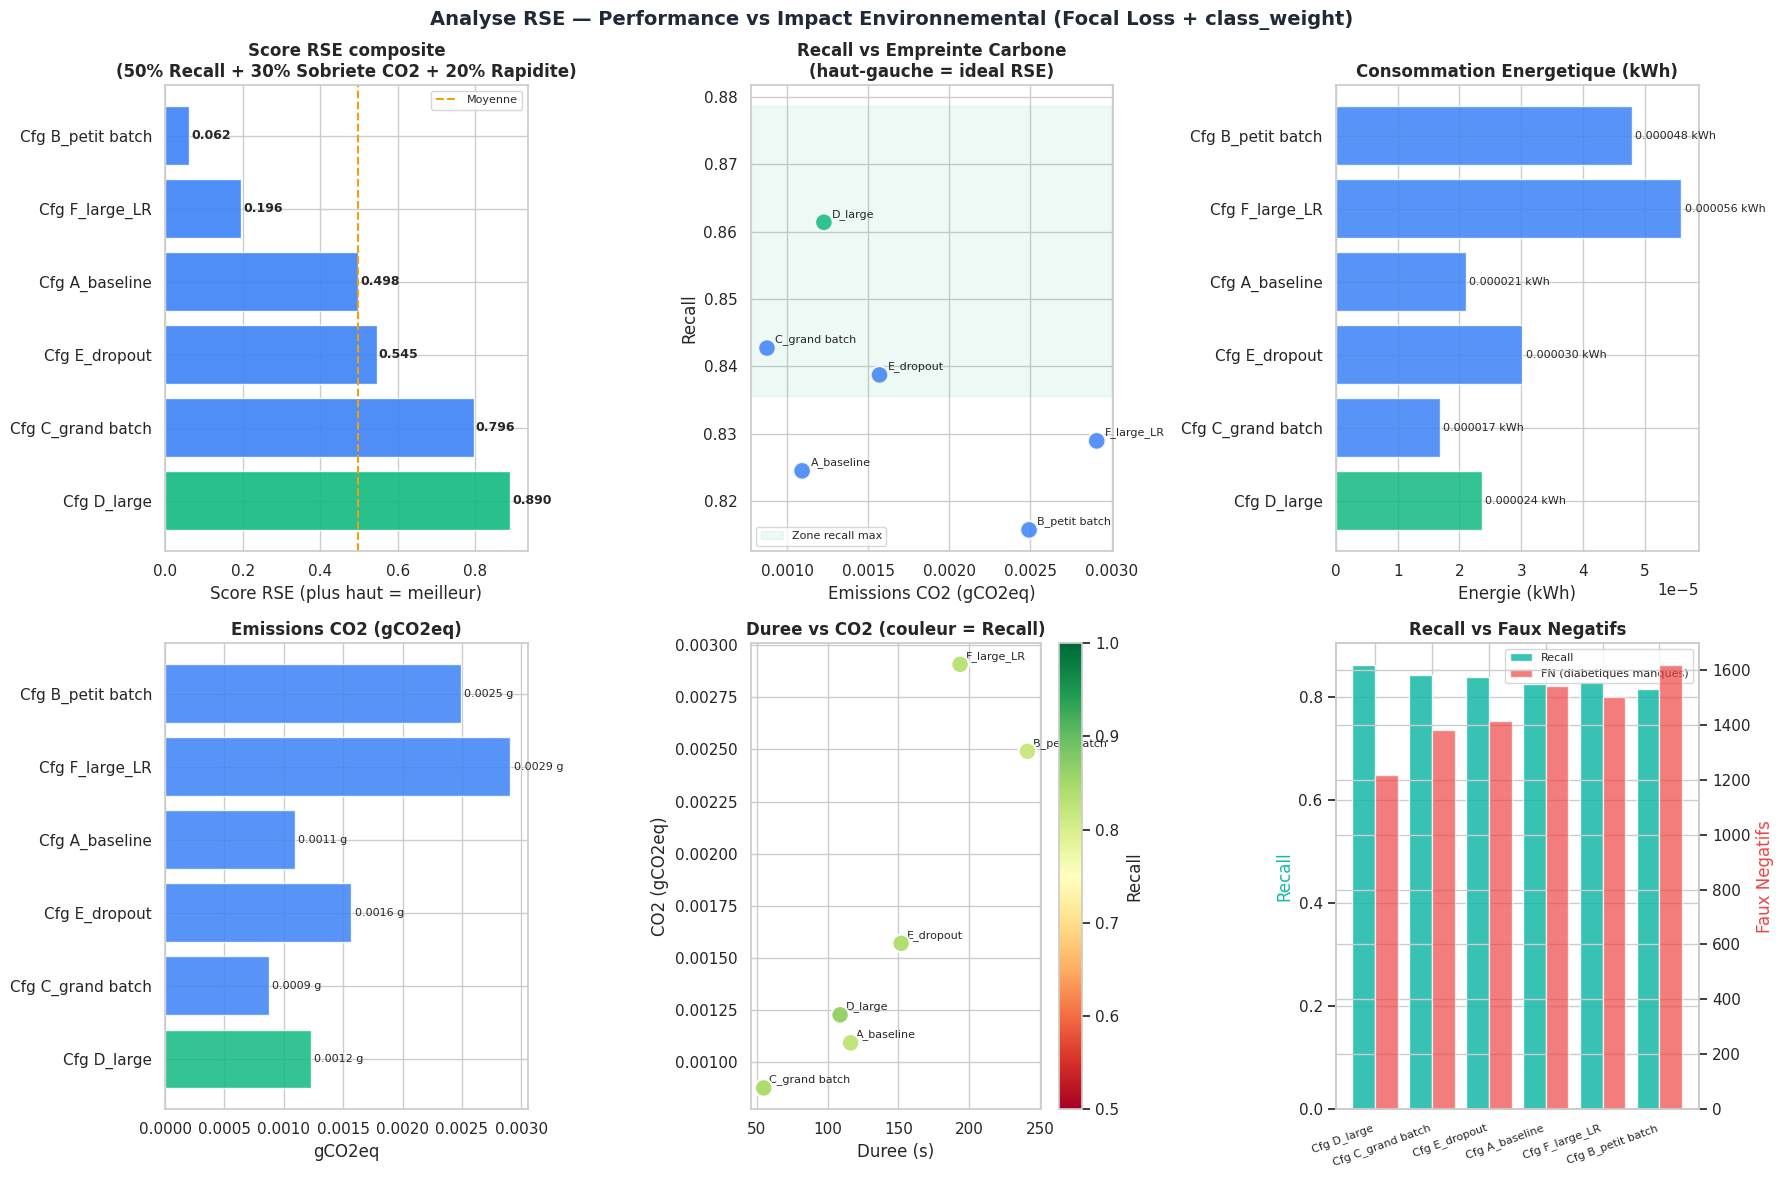

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

labels = df_rse_sorted['config'].str.replace('Config ', 'Cfg ')
best_cfg = best_rse['config']

# Couleurs : vert pour le meilleur score RSE
bar_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
              for c in df_rse_sorted['config']]

# ── 1. Score RSE composite ─────────────────────────────────────────────
bars = axes[0,0].barh(labels, df_rse_sorted['score_rse'],
                      color=bar_colors, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, df_rse_sorted['score_rse']):
    axes[0,0].text(val + 0.005, bar.get_y()+bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Score RSE composite\n(50% Recall + 30% Sobriete CO2 + 20% Rapidite)',
                    fontweight='bold')
axes[0,0].set_xlabel('Score RSE (plus haut = meilleur)')
axes[0,0].axvline(x=df_rse_sorted['score_rse'].mean(), color=COLORS['orange'],
                  lw=1.5, linestyle='--', label='Moyenne')
axes[0,0].legend(fontsize=8)

# ── 2. Scatter Recall vs CO2 (Pareto RSE) ────────────────────────────
scatter_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
                  for c in df_rse['config']]
axes[0,1].scatter(df_rse['co2_g'], df_rse['recall'],
                  color=scatter_colors, s=160, alpha=0.85,
                  edgecolors='white', linewidth=1.5, zorder=5)
for _, row in df_rse.iterrows():
    axes[0,1].annotate(
        row['config'].replace('Config ', ''),
        (row['co2_g'], row['recall']),
        textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[0,1].set_xlabel('Emissions CO2 (gCO2eq)')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Recall vs Empreinte Carbone\n(haut-gauche = ideal RSE)',
                    fontweight='bold')
axes[0,1].axhspan(df_rse['recall'].max()*0.97, df_rse['recall'].max()*1.02,
                  alpha=0.08, color=COLORS['green'], label='Zone recall max')
axes[0,1].legend(fontsize=8)

# ── 3. Consommation energetique ─────────────────────────────────────
bars2 = axes[0,2].barh(labels, df_rse_sorted['energie_kwh'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, df_rse_sorted['energie_kwh']):
    axes[0,2].text(val + df_rse_sorted['energie_kwh'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.6f} kWh', va='center', fontsize=8)
axes[0,2].set_title('Consommation Energetique (kWh)', fontweight='bold')
axes[0,2].set_xlabel('Energie (kWh)')

# ── 4. Emissions CO2 par config ──────────────────────────────────────
bars3 = axes[1,0].barh(labels, df_rse_sorted['co2_g'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, df_rse_sorted['co2_g']):
    axes[1,0].text(val + df_rse_sorted['co2_g'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.4f} g', va='center', fontsize=8)
axes[1,0].set_title('Emissions CO2 (gCO2eq)', fontweight='bold')
axes[1,0].set_xlabel('gCO2eq')

# ── 5. Duree vs CO2 (couleur = Recall) ───────────────────────────────
sc = axes[1,1].scatter(
    df_rse['duree_s'], df_rse['co2_g'],
    c=df_rse['recall'], cmap='RdYlGn', s=160,
    edgecolors='white', linewidth=1.5, vmin=0.5, vmax=1.0, zorder=5)
for _, row in df_rse.iterrows():
    axes[1,1].annotate(row['config'].replace('Config ',''),
                       (row['duree_s'], row['co2_g']),
                       textcoords='offset points', xytext=(4,4), fontsize=8)
plt.colorbar(sc, ax=axes[1,1], label='Recall')
axes[1,1].set_xlabel('Duree (s)')
axes[1,1].set_ylabel('CO2 (gCO2eq)')
axes[1,1].set_title('Duree vs CO2 (couleur = Recall)', fontweight='bold')

# ── 6. Comparaison Recall / FN ───────────────────────────────────────
x = np.arange(len(df_rse_sorted)); w = 0.4
ax6 = axes[1,2]
bars_r = ax6.bar(x - w/2, df_rse_sorted['recall'], w,
                 label='Recall', color=COLORS['teal'], alpha=0.85)
ax6b = ax6.twinx()
bars_fn = ax6b.bar(x + w/2, df_rse_sorted['fn'], w,
                   label='FN (diabetiques manques)', color=COLORS['red'], alpha=0.7)
ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax6.set_ylabel('Recall', color=COLORS['teal'])
ax6b.set_ylabel('Faux Negatifs', color=COLORS['red'])
ax6.set_title('Recall vs Faux Negatifs', fontweight='bold')
lines1, lab1 = ax6.get_legend_handles_labels()
lines2, lab2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')

plt.suptitle('Analyse RSE — Performance vs Impact Environnemental (Focal Loss + class_weight)',
             fontsize=14, fontweight='bold', color=COLORS['dark'])
plt.tight_layout()
plt.show()

In [ ]:
# ── Conclusion RSE ────────────────────────────────────────────────────────
print('=== CONCLUSION RSE ===')
print()
print(f'Modele recommande (meilleur compromis RSE) : {best_rse["config"]}')
print(f'  Score RSE      : {best_rse["score_rse"]:.3f} / 1.000')
print(f'  Recall         : {best_rse["recall"]:.4f}  (objectif medical)')
print(f'  AUC-ROC        : {best_rse["auc"]:.4f}')
print(f'  FN (manques)   : {int(best_rse["fn"]):,}')
print(f'  CO2 estime     : {best_rse["co2_g"]:.6f} gCO2eq  (seuil acceptable : 10g)')
print(f'  Energie        : {best_rse["energie_kwh"]:.8f} kWh')
print(f'  Duree          : {best_rse["duree_s"]:.2f}s')
print(f'  RAM delta      : {best_rse["ram_delta_mb"]:.1f} MB')
print()
print('=== TOP 3 RSE ===')
for i, row in enumerate(df_rse_sorted.head(3).itertuples(), 1):
    print(f'{i}. {row.config}')
    print(f'   Score: {row.score_rse:.3f} | Recall: {row.recall:.4f} | CO2: {row.co2_g:.4f}g | Duree: {row.duree_s:.1f}s')
print()
print('=== SYNTHESE RSE ===')
total_co2   = df_rse['co2_g'].sum()
total_kWh   = df_rse['energie_kwh'].sum()
total_duree = df_rse['duree_s'].sum()
print(f'CO2 total (toutes configs) : {total_co2:.4f} gCO2eq')
print(f'Energie totale             : {total_kWh:.8f} kWh')
print(f'Duree totale               : {total_duree:.1f}s ({total_duree/60:.1f} min)')
print()
seuil_ok = best_rse['co2_g'] < 10
print(f'Conformite seuil CO2 (<10g) : {"OK" if seuil_ok else "ATTENTION"}')
recall_ok = best_rse['recall'] >= 0.70
print(f'Conformite recall (>=0.70)  : {"OK" if recall_ok else "ATTENTION"}')

=== CONCLUSION RSE ===

Modele recommande (meilleur compromis RSE) : Config D_large
  Score RSE      : 0.890 / 1.000
  Recall         : 0.8614  (objectif medical)
  AUC-ROC        : 0.8041
  FN (manques)   : 1,216
  CO2 estime     : 0.001226 gCO2eq  (seuil acceptable : 10g)
  Energie        : 0.00002358 kWh
  Duree          : 108.83s
  RAM delta      : 31.2 MB

=== TOP 3 RSE ===
1. Config D_large
   Score: 0.890 | Recall: 0.8614 | CO2: 0.0012g | Duree: 108.8s
2. Config C_grand batch
   Score: 0.796 | Recall: 0.8427 | CO2: 0.0009g | Duree: 54.8s
3. Config E_dropout
   Score: 0.545 | Recall: 0.8387 | CO2: 0.0016g | Duree: 151.9s

=== SYNTHESE RSE ===
CO2 total (toutes configs) : 0.0102 gCO2eq
Energie totale             : 0.00019543 kWh
Duree totale               : 866.7s (14.4 min)

Conformite seuil CO2 (<10g) : OK
Conformite recall (>=0.70)  : OK


## 9. MLOps — Sauvegarde & Tracking

### Artifacts de production
- `model_production.keras` : meilleur modèle (Config E), poids entraînés.
- `scaler_production.pkl` : StandardScaler pour normaliser les 15 features entrantes.
- `config_production.json` : métadonnées (feature_names, seuil optimal, recall, AUC).

### Tracking des runs
- `mlops_runs.json` : historique de tous les runs (timestamp, config, métriques, promoted=True/False).
- Critères de promotion : AUC ≥ 0.75 ET Recall ≥ 0.70.
- Utile pour audit, rollback, versioning.

### Répertoire cache
- `mlops/cache_models/` : stocke modèle + métadonnées pour chaque config.
- Permet relances rapides sans ré-entraîner.
- Idéal pour notebooks itératifs & ML experiments.



In [ ]:
BASE_DIR = Path.cwd()
MLOPS_DIR = BASE_DIR / 'mlops'
MODELS_DIR = MLOPS_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_FILE = MLOPS_DIR / 'mlops_runs.json'
all_runs = json.loads(RUNS_FILE.read_text(encoding='utf-8')) if RUNS_FILE.exists() else []
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

AUC_MIN=0.75; RECALL_MIN=0.70
model_to_export = best.get('model')
if model_to_export is None:
    best_model_path = best.get('model_path')
    if not best_model_path:
        raise ValueError('model_path manquant pour exporter le meilleur modele')
    model_to_export = keras.models.load_model(
        best_model_path,
        custom_objects={'loss': focal_loss(2.0, 0.75)}
    )

run_entry = {'timestamp':ts,'config':best['config'],'auc':round(best['auc'],4),
    'recall':round(best['recall'],4),'f1':round(best['f1'],4),
    'precision':round(best['precision'],4),'fn':best['fn'],'fp':best['fp'],
    'seuil':round(best['seuil'],4),'epochs':best['epochs'],
    'input_dim':INPUT_DIM,'feature_names':feature_names,
    'class_weight':{str(k):round(v,4) for k,v in CLASS_WEIGHT.items()},
    'focal_loss':True,'promoted':False}

if best['auc']>=AUC_MIN and best['recall']>=RECALL_MIN:
    model_to_export.save(str(MODELS_DIR / f'best_{ts}.keras'))
    with (MODELS_DIR / f'scaler_{ts}.pkl').open('wb') as f: pickle.dump(scaler,f)
    run_entry['promoted']=True
    print('Modele VALIDE et sauvegarde')
else:
    print(f"NON valide : AUC={best['auc']:.4f}(min {AUC_MIN}) Recall={best['recall']:.4f}(min {RECALL_MIN})")

model_to_export.save(str(MLOPS_DIR / 'model_production.keras'))
with (MLOPS_DIR / 'scaler_production.pkl').open('wb') as f: pickle.dump(scaler,f)
with (MLOPS_DIR / 'config_production.json').open('w', encoding='utf-8') as f:
    json.dump({'feature_names':feature_names,'seuil':best['seuil'],
               'config':best['config'],'recall':best['recall'],'auc':best['auc']},f,indent=2)
all_runs.append(run_entry)
RUNS_FILE.write_text(json.dumps(all_runs, indent=2), encoding='utf-8')
print(f'Production pret dans {MLOPS_DIR}  |  {len(all_runs)} runs loggues')


Modele VALIDE et sauvegarde
Production pret dans /home/jxc/CESI/deep_learning/mlops  |  1 runs loggues
